# Example: Longitudinal Analysis of COVID-19 PBMC Data

## Background
Stephenson et al. profiled peripheral blood mononuclear cells (PBMCs) from COVID‑19 patients across severity groups and timepoints, providing a longitudinal view of immune dynamics during disease progression. Here we illustrate trial-style longitudinal analyses using **sctrial**.

**Important note:** Severity (Severe vs Mild) is observational, not randomized. These analyses are descriptive; DiD helps control time‑invariant differences but does **not** establish causality. We also keep **one primary time axis** (DFO *or* Collection_Day) throughout to avoid mixing timelines.


## 1. Setup
Here, we configure notebook settings and import the packages used throughout the analysis.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import statsmodels.formula.api as smf
import sctrial as st

pd.options.mode.chained_assignment = None


## 2. Data Loading and Processing
We define the loader function separately, then load the processed AnnData and inspect its contents in dedicated cells.


In [2]:
from pathlib import Path
import urllib.request
import numpy as np
import scipy.sparse as sp


def _resolve_file(p: str) -> Path:
    path = Path(p)
    if path.is_absolute() and path.exists():
        return path
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / path
        if cand.exists():
            return cand
    return path


def _resolve_dir_with_files(p: str, required_files) -> Path:
    path = Path(p)
    if path.is_absolute():
        if all((path / f).exists() for f in required_files):
            return path
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / path
        if all((cand / f).exists() for f in required_files):
            return cand
    return path


def _download_if_missing(url: str, dest: Path, allow_download: bool = False) -> None:
    if dest.exists():
        return
    if not allow_download:
        raise FileNotFoundError(
            f"Missing file: {dest}. Download from: {url}"
        )
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, dest)


def _counts_like(X, sample: int = 10000, seed: int = 0) -> bool:
    if X is None:
        return False
    if sp.issparse(X):
        data = X.data
    else:
        data = np.asarray(X).ravel()
    if data.size == 0:
        return False
    data = data[np.isfinite(data)]
    if data.size == 0:
        return False
    rng = np.random.default_rng(seed)
    if data.size > sample:
        data = rng.choice(data, size=sample, replace=False)
    if data.min() < 0:
        return False
    return np.allclose(data, np.round(data), atol=1e-3)


def _get_counts_matrix(adata):
    if "counts" in adata.layers and _counts_like(adata.layers["counts"]):
        return adata.layers["counts"], "layers['counts']"
    if getattr(adata, "raw", None) is not None:
        if list(adata.raw.var_names) == list(adata.var_names) and _counts_like(adata.raw.X):
            return adata.raw.X, "adata.raw.X"
    if "raw" in adata.layers and _counts_like(adata.layers["raw"]):
        return adata.layers["raw"], "layers['raw']"
    if _counts_like(adata.X):
        return adata.X, "adata.X"
    return None, None


def load_stephenson_example_data(
    data_path="data/stephenson/covid_portal_210320_with_raw.h5ad",
    processed_name="stephenson_covid19_processed.h5ad",
    max_participants_per_arm=40,
    max_cells_per_group=200,
    seed=42,
    allow_download=False,
    force_reprocess=False,
):
    data_path = _resolve_file(data_path)

    data_root = data_path.parent.parent if data_path.exists() else _resolve_dir_with_files(
        "data/stephenson", ["covid_portal_210320_with_raw.h5ad"]
    ).parent
    processed_path = data_root / "processed" / processed_name

    processing_params = {
        "version": "v2",
        "max_participants_per_arm": max_participants_per_arm,
        "max_cells_per_group": max_cells_per_group,
        "seed": seed,
        "visit_bins": [-1, 7, 14],
        "arms": ["Mild", "Severe"],
    }

    if processed_path.exists() and not force_reprocess:
        adata = sc.read_h5ad(processed_path)
        prev = adata.uns.get("processing_params", {})
        if prev == processing_params:
            print(f"Loaded processed Stephenson dataset: {adata.n_obs} cells, {adata.n_vars} genes")
            print("Processed file:", processed_path)
            # ensure counts layer if possible
            X_counts, source = _get_counts_matrix(adata)
            if X_counts is not None and "counts" not in adata.layers:
                adata.layers["counts"] = X_counts
                print(f"Counts layer set from {source}")
            print("Arms:", adata.obs["arm"].unique())
            print("Visits (DFO):", adata.obs["visit"].unique())
            if "visit_collection" in adata.obs:
                print("Visits (Collection_Day):", adata.obs["visit_collection"].unique())
            print("Cell types:", adata.obs["cell_type_fine"].nunique())
            return adata
        else:
            print("Processed file parameters differ; reprocessing.")

    url = "https://www.ebi.ac.uk/biostudies/files/E-MTAB-10026/covid_portal_210320_with_raw.h5ad"
    _download_if_missing(url, data_path, allow_download=allow_download)

    adata = sc.read_h5ad(data_path)

    # counts handling
    X_counts, source = _get_counts_matrix(adata)
    if X_counts is None:
        raise ValueError("No raw counts detected. Please provide counts in adata.layers['counts'] or adata.raw.X.")
    adata.layers["counts"] = X_counts
    print(f"Counts source: {source}")

    obs = adata.obs.copy()
    obs["arm"] = obs["Status_on_day_collection_summary"].astype(str)
    obs = obs[obs["arm"].isin(["Mild", "Severe"])].copy()
    if obs.empty:
        raise ValueError("No Mild/Severe cells found after filtering.")

    obs["days_from_onset_num"] = pd.to_numeric(obs["Days_from_onset"], errors="coerce")
    obs["visit"] = pd.cut(
        obs["days_from_onset_num"],
        bins=[-1, 7, 14],
        labels=["0-7", "8-14"],
    ).astype(str)
    obs = obs[obs["visit"].isin(["0-7", "8-14"])].copy()

    if "Collection_Day" in obs.columns:
        obs["visit_collection"] = obs["Collection_Day"].astype(str)

    obs["participant_id"] = obs["patient_id"].astype(str)
    obs["cell_type_fine"] = obs["full_clustering"].astype(str)

    adata = adata[obs.index].copy()
    adata.obs = obs

    rng = np.random.default_rng(seed)
    mild_ids = adata.obs.loc[adata.obs["arm"] == "Mild", "participant_id"].unique()
    severe_ids = adata.obs.loc[adata.obs["arm"] == "Severe", "participant_id"].unique()
    n = min(len(mild_ids), len(severe_ids)) if max_participants_per_arm is None else min(len(mild_ids), len(severe_ids), max_participants_per_arm)
    if n == 0:
        raise ValueError("Not enough Mild/Severe participants after filtering.")
    sel = set(rng.choice(mild_ids, size=n, replace=False)) | set(
        rng.choice(severe_ids, size=n, replace=False)
    )
    adata = adata[adata.obs["participant_id"].isin(sel)].copy()

    if max_cells_per_group is not None:
        grp = ["participant_id", "visit", "arm", "cell_type_fine"]
        sampled = (
            adata.obs.groupby(grp, observed=True, group_keys=False)
            .apply(lambda x: x.sample(min(len(x), max_cells_per_group), random_state=seed))
        )
        adata = adata[sampled.index].copy()

    adata.uns["processing_params"] = processing_params

    processed_path.parent.mkdir(parents=True, exist_ok=True)
    adata.write_h5ad(processed_path)
    print("Saved processed file:", processed_path)

    print(
        f"Loaded Stephenson COVID-19 dataset: {adata.n_obs} cells, {adata.n_vars} genes"
    )
    print("Arms:", adata.obs["arm"].unique())
    print("Visits (DFO):", adata.obs["visit"].unique())
    if "visit_collection" in adata.obs:
        print("Visits (Collection_Day):", adata.obs["visit_collection"].unique())
    print("Cell types:", adata.obs["cell_type_fine"].nunique())

    return adata


### 2.1 Load processed AnnData
We load the processed dataset and display basic structure/metadata.


In [3]:
adata = load_stephenson_example_data(
    max_participants_per_arm=None,
    max_cells_per_group=None,
    force_reprocess=True,
)

print(adata)
print("Obs columns:")
print(sorted(adata.obs.columns.tolist()))


Loaded processed Stephenson dataset: 37709 cells, 24929 genes
Processed file: /Users/omarm/Documents/Research/projects/sc-trialdiff/data/processed/stephenson_covid19_processed.h5ad
Arms: ['Mild', 'Severe']
Categories (2, object): ['Mild', 'Severe']
Visits (DFO): ['0-7', '8-14']
Categories (2, object): ['0-7', '8-14']
Visits (Collection_Day): ['D0', 'D28']
Categories (2, object): ['D0', 'D28']
Cell types: 50
AnnData object with n_obs × n_vars = 37709 × 24929
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', 'arm', 'days_from_onset_num', 'visit', 'visit_collection', 'participant_id', 'cell_type_fine'
    var: 'feature_types'
    uns: 'hvg', 'leiden',

### 2.2 Quick exploratory summaries
We summarize sample sizes across arms and visits and inspect key distributions.


Arms: ['Mild', 'Severe']
Categories (2, object): ['Mild', 'Severe']
Visits (DFO): ['0-7', '8-14']
Categories (2, object): ['0-7', '8-14']
Visits (Collection_Day): ['D0', 'D28']
Categories (2, object): ['D0', 'D28']
Cell types: 50


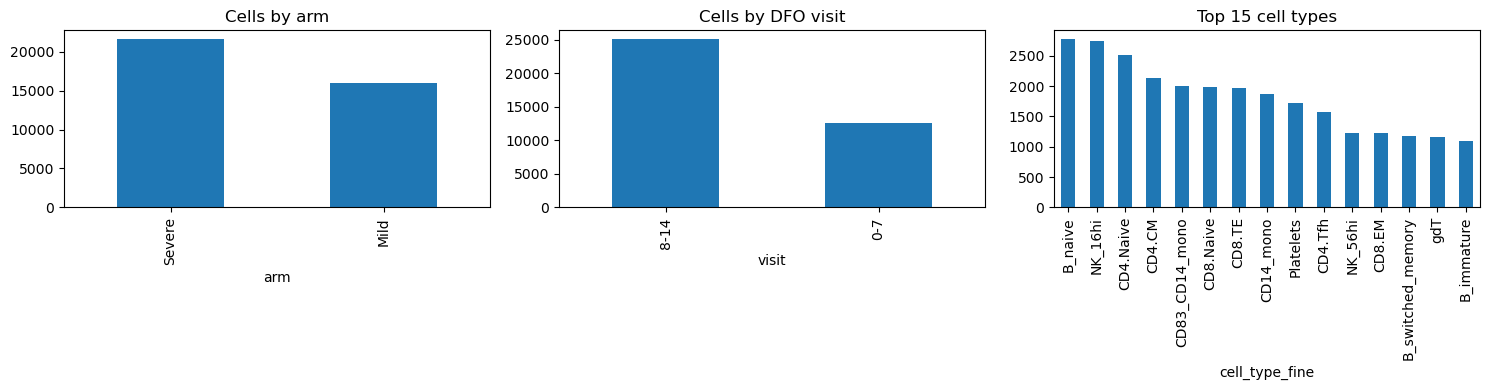

In [4]:
print("Arms:", adata.obs["arm"].unique())
print("Visits (DFO):", adata.obs["visit"].unique())
if "visit_collection" in adata.obs:
    print("Visits (Collection_Day):", adata.obs["visit_collection"].unique())
print("Cell types:", adata.obs["cell_type_fine"].nunique())

# Basic counts
arm_counts = adata.obs["arm"].value_counts()
visit_counts = adata.obs["visit"].value_counts()
ct_counts = adata.obs["cell_type_fine"].value_counts().head(15)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
arm_counts.plot(kind="bar", ax=axes[0], title="Cells by arm")
visit_counts.plot(kind="bar", ax=axes[1], title="Cells by DFO visit")
ct_counts.plot(kind="bar", ax=axes[2], title="Top 15 cell types")
plt.tight_layout(); plt.show()


## 3. Trial Design and Timepoint Strategy
Here, we define the trial design and choose a **single primary time axis** (DFO or Collection_Day). All downstream analyses use that same axis for consistency.


In [5]:
def _looks_log1p(X, sample: int = 10000, seed: int = 0) -> bool:
    if X is None:
        return False
    if sp.issparse(X):
        data = X.data
    else:
        data = np.asarray(X).ravel()
    if data.size == 0:
        return False
    data = data[np.isfinite(data)]
    if data.size == 0:
        return False
    rng = np.random.default_rng(seed)
    if data.size > sample:
        data = rng.choice(data, size=sample, replace=False)
    return (data.min() >= 0) and (data.max() < 50) and (not np.allclose(data, np.round(data), atol=1e-3))


def _paired_participants(obs, participant_col, visit_col, visits):
    wide = obs.pivot_table(index=participant_col, columns=visit_col, aggfunc="size", fill_value=0, observed=True)
    keep = wide[(wide.get(visits[0], 0) > 0) & (wide.get(visits[1], 0) > 0)].index
    return set(keep)


# ensure log1p_cpm from true counts when possible
X_counts, counts_source = _get_counts_matrix(adata)
if X_counts is not None:
    if "counts" not in adata.layers:
        adata.layers["counts"] = X_counts
    if "log1p_cpm" not in adata.layers:
        adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")
        print(f"Added log1p_cpm from {counts_source}")
else:
    if "log1p_cpm" not in adata.layers and _looks_log1p(adata.X):
        adata.layers["log1p_cpm"] = adata.X.copy()
        print("Using adata.X as log1p_cpm (appears already log-transformed)")
    else:
        raise ValueError("No raw counts or log1p expression found; cannot proceed.")

# choose primary visit strategy (DFO preferred, Collection_Day fallback for pairing)
visit_col = "visit"
adata.obs[visit_col] = adata.obs[visit_col].astype(str)
visits = [v for v in ["0-7", "8-14"] if v in adata.obs[visit_col].unique()]
paired_ids = _paired_participants(adata.obs, "participant_id", visit_col, visits) if len(visits) == 2 else set()

if len(paired_ids) < 4 and "visit_collection" in adata.obs:
    visit_col = "visit_collection"
    adata.obs[visit_col] = adata.obs[visit_col].astype(str)
    visits = [v for v in ["D0", "D28"] if v in adata.obs[visit_col].unique()]
    paired_ids = _paired_participants(adata.obs, "participant_id", visit_col, visits) if len(visits) == 2 else set()

n_paired = len(paired_ids)
print(f"Primary visit_col: {visit_col}; visits: {visits}; paired participants: {n_paired}")

# candidate covariates (only keep those present)
candidate_covariates = [
    "age", "age_years", "sex", "sex_at_birth", "batch", "site", "donor", "sampling_center"
]
covariates = [c for c in candidate_covariates if c in adata.obs.columns]
print("Covariates used (if any):", covariates)

# Trial design
adata.obs[visit_col] = adata.obs[visit_col].astype(str)

design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col="arm",
    arm_treated="Severe",
    arm_control="Mild",
    celltype_col="cell_type_fine",
)

# Visits to use for cross-sectional summaries on the same axis
if visit_col == "visit":
    cross_visits = [v for v in ["0-7", "8-14"] if v in adata.obs[visit_col].unique()]
else:
    cross_visits = [v for v in ["D0", "D7", "D9", "D12", "D13", "D28"] if v in adata.obs[visit_col].unique()]

print("Using visit_col:", visit_col, "visits:", visits, "cross_visits:", cross_visits)


Paired participants (DFO 0-7 vs 8-14): 0
Paired participants (Collection_Day D0 vs D28): 2
Using visit_col: visit_collection visits: ['D0', 'D28']


### 3.1 Exploratory plots of cell types per visit
We visualize how cell‑type distributions shift across visits and arms.


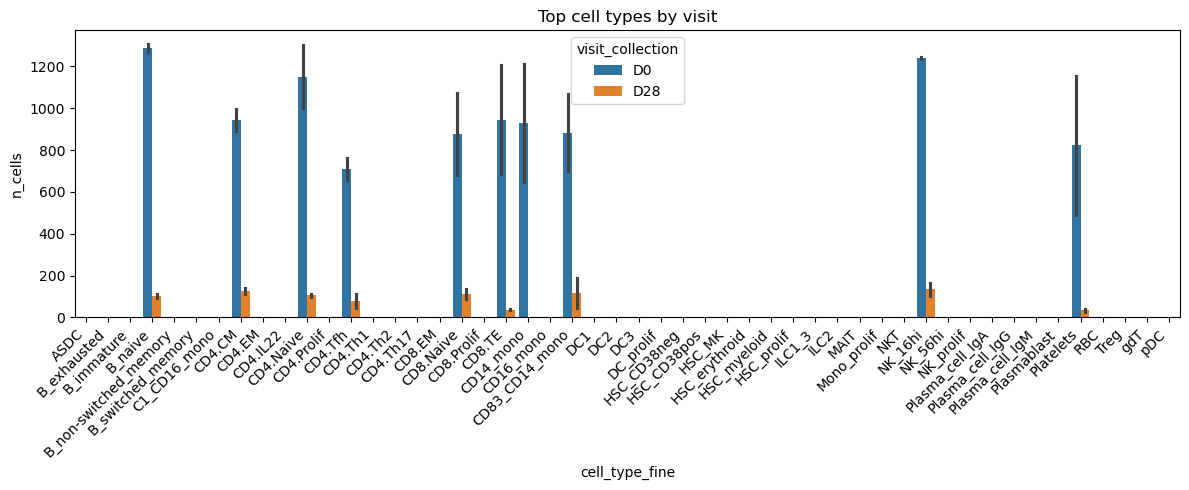

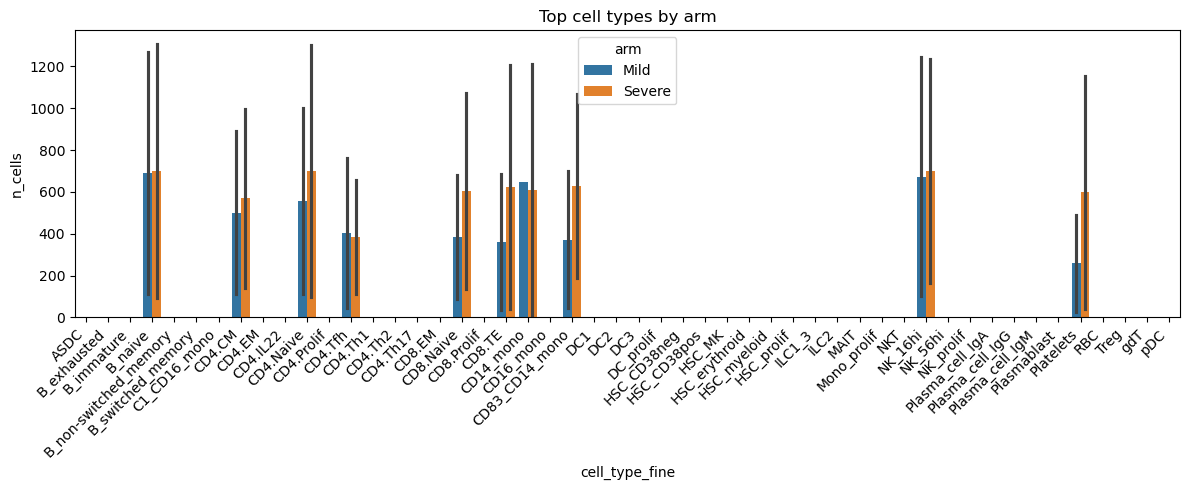

In [6]:
# Counts by visit and arm
ct_visit = (
    adata.obs
    .groupby([design.celltype_col, design.visit_col, design.arm_col], observed=True)
    .size()
    .reset_index(name="n_cells")
)

# Plot top cell types
top_ct = adata.obs[design.celltype_col].value_counts().head(10).index
ct_visit_top = ct_visit[ct_visit[design.celltype_col].isin(top_ct)].copy()

plt.figure(figsize=(12, 5))
sns.barplot(data=ct_visit_top, x=design.celltype_col, y="n_cells", hue=design.visit_col)
plt.title("Top cell types by visit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=ct_visit_top, x=design.celltype_col, y="n_cells", hue=design.arm_col)
plt.title("Top cell types by arm")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


## 4. UMAPs of All Cell Types
Here, we visualize global cell‑type structure and stratify by arm × visit. Legends are placed on the right for readability.


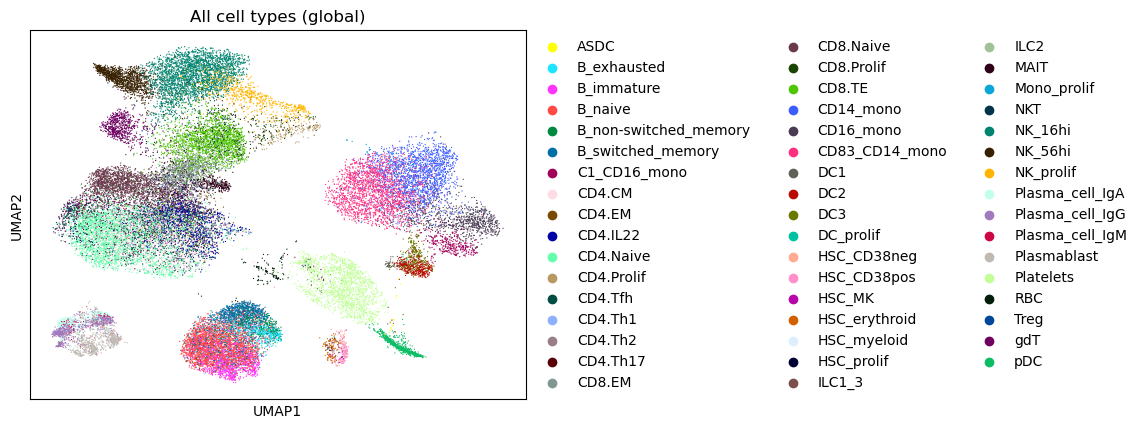

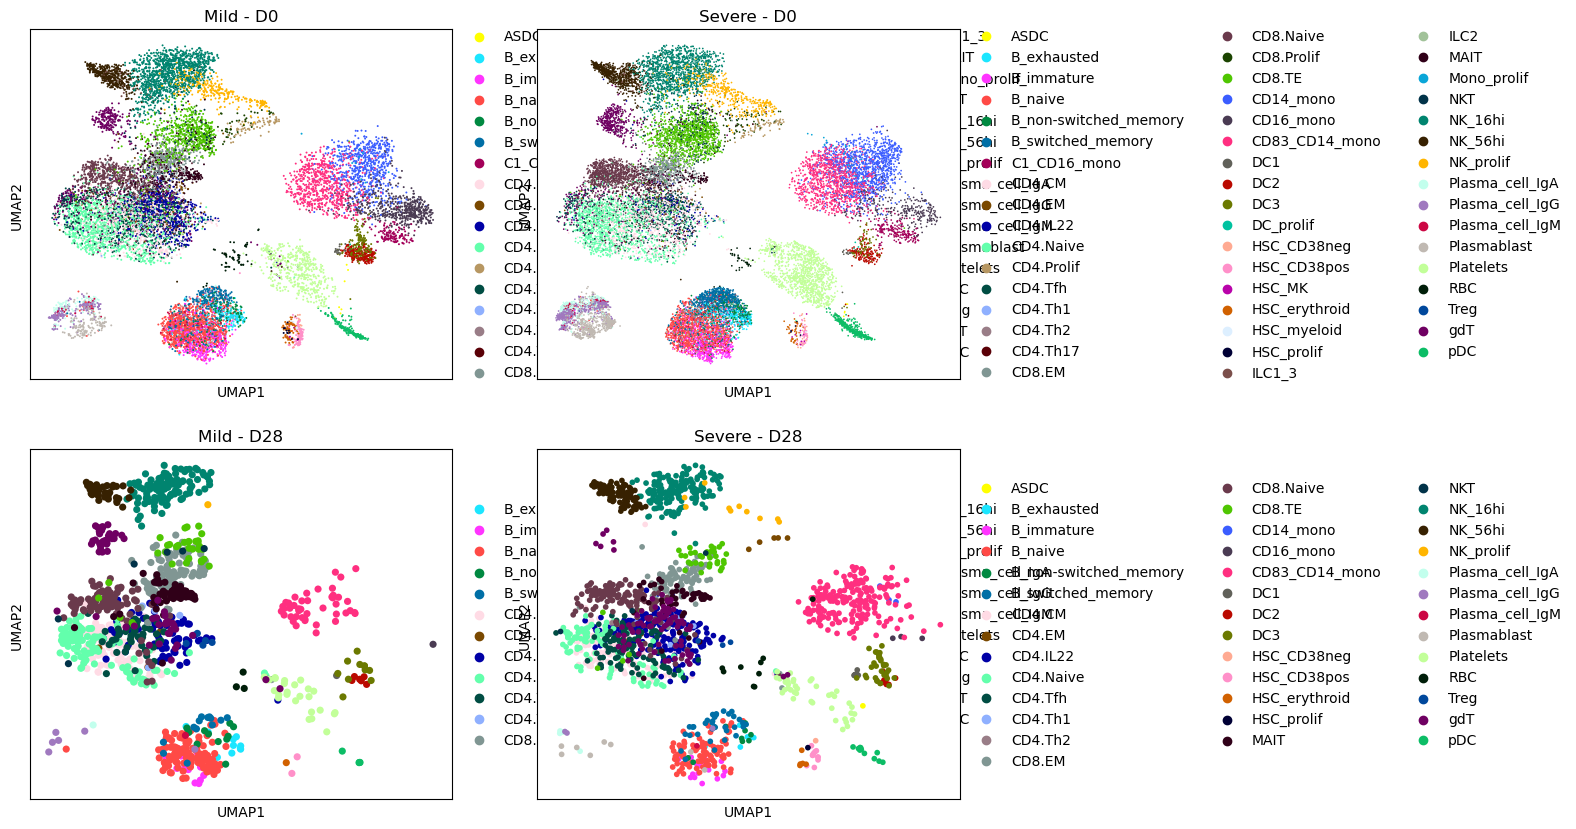

In [7]:
# Compute UMAP if missing
if "X_umap" not in adata.obsm:
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Global cell-type UMAP
sc.pl.umap(
    adata,
    color=design.celltype_col,
    legend_loc="right margin",
    title="All cell types (global)",
)

# 2x2 stratified UMAPs by arm × visit
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, arm in enumerate([design.arm_control, design.arm_treated]):
    for j, vis in enumerate(visits):
        sub = adata[(adata.obs[design.arm_col] == arm) & (adata.obs[design.visit_col] == vis)].copy()
        ax = axes[j, i] if len(visits) == 2 else axes[0, i]
        if sub.n_obs > 0:
            sc.pl.umap(
                sub,
                color=design.celltype_col,
                ax=ax,
                show=False,
                legend_loc="right margin",
            )
            ax.set_title(f"{arm} - {vis}")
        else:
            ax.set_axis_off()
            ax.set_title(f"{arm} - {vis} (no cells)")
plt.tight_layout(); plt.show()


## 5. Module Scoring and Gene Panel
We construct module scores and define a focused gene panel for downstream contrasts.


In [8]:
available = set(adata.var_names)

min_genes = 5

gene_sets = {
    "IFN_Response": [g for g in [
        "ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "MX2", "STAT1", "STAT2",
        "OAS1", "OAS2", "OAS3", "IRF7", "IFITM1", "IFITM3"
    ] if g in available],
    "B_Cell_Activation": [g for g in [
        "MS4A1", "CD19", "CD79A", "CD79B", "BANK1", "HLA-DRA", "HLA-DRB1",
        "CD74", "SPIB", "TNFRSF13B"
    ] if g in available],
    "T_Cell_Activation": [g for g in [
        "CD3D", "CD3E", "TRBC1", "TRBC2", "IL7R", "LST1", "CCR7", "MALAT1",
        "LTB", "ICOS", "CTLA4"
    ] if g in available],
    "Inflammation": [g for g in [
        "S100A8", "S100A9", "LYZ", "VCAN", "IL1B", "CXCL8", "TNF", "NFKBIA",
        "CCL2", "CCL3"
    ] if g in available],
    "Myeloid": [g for g in [
        "LYZ", "CTSS", "CST3", "LGALS3", "FCGR3A", "LST1", "TYMP", "CTSD",
        "AIF1", "SPI1"
    ] if g in available],
}

gene_sets = {k: v for k, v in gene_sets.items() if len(v) >= min_genes}
if gene_sets:
    adata = st.score_gene_sets(adata, gene_sets, layer="log1p_cpm", method="mean", prefix="ms_")
else:
    print("No gene sets matched this dataset (min_genes={min_genes}); skipping module scoring.")

panel_genes = [g for g in [
    "ISG15", "IFI6", "IFIT1", "IFIT3", "MX1", "MX2",
    "S100A8", "S100A9", "LYZ", "VCAN",
    "MS4A1", "CD19", "CD79A", "CTSS", "FCGR3A",
] if g in available]

features = [c for c in adata.obs.columns if c.startswith("ms_")]
print("Module score features:", features)
print("Panel genes:", panel_genes)


Module score features: ['ms_IFN_Response', 'ms_B_Cell_Activation', 'ms_Inflammation', 'ms_Myeloid']
Panel genes: ['ISG15', 'IFI6', 'MX1', 'S100A8', 'S100A9', 'LYZ', 'MS4A1', 'CD19', 'CTSS', 'FCGR3A']


## 6. Cross‑Sectional Comparisons by Timepoint
Given limited pairing, we compare arms within each available Collection_Day (if present) to capture more granular differences.


In [9]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import statsmodels.formula.api as smf


def _extract_gene_matrix(ad, genes, layer=None):
    ad_sub = ad[:, genes]
    X = ad_sub.layers[layer] if layer is not None else ad_sub.X
    if sp.issparse(X):
        X = X.toarray()
    else:
        X = np.asarray(X)
    return pd.DataFrame(X, columns=genes, index=ad_sub.obs_names)


def between_arm_ols_adjusted(
    adata,
    visit,
    features,
    design,
    covariates=None,
    layer=None,
    agg="mean",
    adjust_celltype=True,
):
    ad = adata[adata.obs[design.visit_col] == visit].copy()
    if ad.n_obs == 0:
        return pd.DataFrame()

    obs = ad.obs.copy()
    obs["arm_bin"] = (obs[design.arm_col] == design.arm_treated).astype(int)

    cols = [design.participant_col, "arm_bin", design.arm_col]
    if adjust_celltype and design.celltype_col:
        cols.append(design.celltype_col)

    df = obs[cols].copy()

    genes = [f for f in features if f in ad.var_names and f not in ad.obs.columns]
    if genes:
        df_genes = _extract_gene_matrix(ad, genes, layer=layer)
        df = df.join(df_genes, how="left")

    for feat in features:
        if feat in ad.obs.columns:
            df[feat] = ad.obs[feat].values

    # aggregate per participant (and celltype, if requested)
    grp_cols = [design.participant_col, "arm_bin", design.arm_col]
    if adjust_celltype and design.celltype_col:
        grp_cols.append(design.celltype_col)

    agg_map = {f: agg for f in features}
    if covariates:
        for c in covariates:
            if c in obs.columns:
                df[c] = obs[c].values
                agg_map[c] = "first"
                if c not in grp_cols:
                    grp_cols.append(c)

    df_use = df.groupby(grp_cols, observed=True).agg(agg_map).reset_index()

    rows = []
    base_covars = []
    if covariates:
        base_covars.extend([c for c in covariates if c in df_use.columns])
    if adjust_celltype and design.celltype_col:
        base_covars.append(f"C({design.celltype_col})")

    for feat in features:
        if feat not in df_use.columns:
            continue
        yy = df_use[feat].astype(float)
        df_use["_y"] = (yy - yy.mean()) / (yy.std(ddof=1) + 1e-12)
        formula = "_y ~ arm_bin"
        if base_covars:
            formula += " + " + " + ".join(base_covars)
        fit = smf.ols(formula, data=df_use).fit()
        rows.append({
            "feature": feat,
            "beta_arm": float(fit.params.get("arm_bin", np.nan)),
            "p_arm": float(fit.pvalues.get("arm_bin", np.nan)),
            "n_units": int(df_use[design.participant_col].nunique()),
        })

    out = pd.DataFrame(rows).sort_values("p_arm") if rows else pd.DataFrame()
    return out


if features:
    for v in cross_visits:
        print(f"Between-arm comparisons at {v} (OLS, participant-level, celltype-adjusted):")
        res_ols = between_arm_ols_adjusted(
            adata,
            visit=v,
            features=features,
            design=design,
            covariates=covariates,
            layer=None,
            agg="mean",
            adjust_celltype=True,
        )
        if not res_ols.empty:
            display(res_ols.set_index("feature"))
else:
    print("No module scores available; skipping cross-sectional comparisons.")


Between-arm comparisons at D0 (OLS):


,beta_arm,p_arm,n_units,FDR_arm
feature,,,,
ms_IFN_Response,0.087398,0.877659,14,0.877659
ms_B_Cell_Activation,0.214494,0.704848,14,0.877659
ms_Inflammation,0.445781,0.426234,14,0.877659
ms_Myeloid,0.157126,0.781725,14,0.877659


Between-arm comparisons at D0 (Wilcoxon):


,beta_arm,p_arm,n_units,FDR_arm
feature,,,,
ms_IFN_Response,0.095981,0.804779,14,0.804779
ms_B_Cell_Activation,0.085870,0.382867,14,0.765734
ms_Inflammation,0.427638,0.208625,14,0.765734
ms_Myeloid,0.077516,0.710373,14,0.804779


Between-arm comparisons at D28 (OLS):


,beta_arm,p_arm,n_units,FDR_arm
feature,,,,
ms_IFN_Response,1.414214,NaN,2,NaN
ms_B_Cell_Activation,-1.414214,NaN,2,NaN
ms_Inflammation,1.414214,NaN,2,NaN
ms_Myeloid,1.414214,NaN,2,NaN


Between-arm comparisons at D28 (Wilcoxon):


,beta_arm,p_arm,n_units,FDR_arm
feature,,,,
ms_IFN_Response,0.625242,1.0,2,1.0
ms_B_Cell_Activation,-0.198913,1.0,2,1.0
ms_Inflammation,0.442688,1.0,2,1.0
ms_Myeloid,0.545110,1.0,2,1.0


## 7. Difference‑in‑Differences (Module Scores)
We run DiD when paired data are sufficient, using wild‑bootstrap p‑values to stabilize inference.


In [10]:
if features and n_paired >= 4 and len(visits) == 2:
    cov_did = list(covariates)
    if design.celltype_col:
        cov_did.append(design.celltype_col)
    did = st.did_table(
        adata,
        features=features,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit_celltype",
        standardize=True,
        use_bootstrap=True,
        n_boot=199,
        covariates=cov_did,
    )
    print("DiD (module scores, participant-level, celltype-adjusted, bootstrap p):")
    if not did.empty:
        display(did.set_index("feature"))
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        st.plot_did_forest(did, ax=ax)
        plt.tight_layout(); plt.show()
else:
    print("DiD requires >=4 paired participants and 2 visits; skipping.")


DiD requires >=4 paired participants and 2 visits; skipping.


## 8. Participant‑Level DiD (Fixed Effects)
This section uses participant‑level aggregation to avoid treating cells as independent observations.


In [11]:
if features and n_paired >= 4 and len(visits) == 2:
    cov_did = list(covariates)
    if design.celltype_col:
        cov_did.append(design.celltype_col)
    did_part = st.did_table(
        adata,
        features=features,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        standardize=True,
        covariates=cov_did,
    )
    print("DiD (module scores, participant-level FE):")
    if not did_part.empty:
        display(did_part.set_index("feature"))
else:
    print("Insufficient paired participants for participant-level DiD.")


Insufficient paired participants for cell-level DiD.


## 9. DiD by Cell Type (Top 6)
We stratify DiD by the most abundant cell types to identify lineage‑specific effects.


In [12]:
if features and n_paired >= 4 and len(visits) == 2:
    top_ct = adata.obs[design.celltype_col].value_counts().head(6).index.tolist()
    did_ct = st.did_table_by_celltype(
        adata,
        features=features,
        design=design,
        visits=tuple(visits),
        celltypes=top_ct,
        aggregate="participant_visit",
        covariates=covariates,
    )
    print("DiD by cell type (top 6 cell types):")
    if not did_ct.empty:
        display(did_ct.set_index(["celltype", "feature"]))
else:
    print("Insufficient paired participants for cell-type DiD.")


Insufficient paired participants for cell-type DiD.


## 10. Cell‑Type Abundance DiD
We quantify changes in cell‑type proportions across time using DiD on proportions.


In [13]:
if n_paired >= 4 and len(visits) == 2:
    ab_res = st.abundance_did(
        adata,
        design=design,
        visits=tuple(visits),
        transform="arcsin_sqrt",
        min_units=4,
        use_bootstrap=True,
        n_boot=199,
        covariates=covariates,
    )
    print("Abundance DiD (arcsin_sqrt, bootstrap):")
    if not ab_res.empty:
        display(ab_res.set_index("celltype"))
else:
    print("Insufficient paired participants for abundance DiD.")


Insufficient paired participants for abundance DiD.


## 11. Gene Expression DiD (Panel Genes)
We apply DiD to a focused immune gene panel as an interpretable transcript‑level analysis.


In [14]:
if panel_genes and n_paired >= 4 and len(visits) == 2:
    cov_did = list(covariates)
    if design.celltype_col:
        cov_did.append(design.celltype_col)
    did_genes = st.did_table(
        adata,
        features=panel_genes,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit_celltype",
        layer="log1p_cpm",
        standardize=True,
        use_bootstrap=True,
        n_boot=199,
        covariates=cov_did,
    )
    print("Gene-expression DiD (panel genes, celltype-adjusted, bootstrap):")
    if not did_genes.empty:
        display(did_genes.set_index("feature"))
else:
    print("Insufficient paired participants for gene-level DiD.")


Insufficient paired participants for gene-level DiD.


## 12. Pseudobulk DiD
Here, we aggregate to participant × visit × cell type and run DiD on pseudobulked expression.


In [15]:
import scipy.sparse as sp

if panel_genes and n_paired >= 4 and len(visits) == 2:
    if "counts" not in adata.layers:
        print("Counts layer missing; cannot run pseudobulk DiD.")
    else:
        Xc = adata.layers["counts"]
        if sp.issparse(Xc):
            Xc = Xc.tocsr()
        gene_idx = [adata.var_names.get_loc(g) for g in panel_genes]
        X_panel = Xc[:, gene_idx]
        if sp.issparse(X_panel):
            X_panel = X_panel.toarray()

        df_expr = pd.DataFrame(X_panel, columns=panel_genes, index=adata.obs_names)
        df_meta = adata.obs[["participant_id", design.arm_col, design.visit_col, design.celltype_col]].copy()
        df = df_meta.join(df_expr, how="left")

        # sum counts per participant x visit x celltype
        df_sum = (
            df.groupby(["participant_id", design.arm_col, design.visit_col, design.celltype_col], observed=True)
              .sum(numeric_only=True)
              .reset_index()
        )
        # total counts per sample for CPM
        totals = df_sum[panel_genes].sum(axis=1).values.reshape(-1, 1)
        cpm = df_sum[panel_genes].values / (totals + 1e-12) * 1e6
        df_sum[panel_genes] = np.log1p(cpm)

        df_sum[design.visit_col] = pd.Categorical(df_sum[design.visit_col], categories=list(visits), ordered=True)
        df_sum["visit_num"] = df_sum[design.visit_col].map({visits[0]: 0, visits[1]: 1}).astype(float)
        df_sum["arm_bin"] = (df_sum[design.arm_col] == design.arm_treated).astype(int)

        results = []
        for ct in df_sum[design.celltype_col].unique():
            sub = df_sum[df_sum[design.celltype_col] == ct].copy()
            wide = sub.pivot_table(index="participant_id", columns=design.visit_col, aggfunc="size", fill_value=0, observed=True)
            keep = wide[(wide.get(visits[0], 0) > 0) & (wide.get(visits[1], 0) > 0)].index
            sub = sub[sub["participant_id"].isin(keep)].copy()
            if sub["participant_id"].nunique() < 4:
                continue
            for g in panel_genes:
                y = sub[g].astype(float)
                sub["_y"] = (y - y.mean()) / (y.std(ddof=1) + 1e-12)
                model = smf.ols("_y ~ visit_num + visit_num:arm_bin + C(participant_id)", data=sub)
                fit = model.fit(cov_type="cluster", cov_kwds={"groups": sub["participant_id"]})
                term = "visit_num:arm_bin"
                results.append({
                    "celltype": ct,
                    "feature": g,
                    "beta_DiD": float(fit.params.get(term, np.nan)),
                    "se_DiD": float(fit.bse.get(term, np.nan)),
                    "p_DiD": float(fit.pvalues.get(term, np.nan)),
                    "n_units": int(sub["participant_id"].nunique()),
                })

        pb_res = pd.DataFrame(results)
        print("Pseudobulk DiD (panel genes × cell type, log1p CPM from summed counts):")
        if not pb_res.empty:
            display(pb_res.sort_values("p_DiD").head(50))
else:
    print("Insufficient paired participants for pseudobulk DiD.")


Insufficient paired participants for pseudobulk DiD.


## 13. Preranked GSEA DiD
We run preranked GSEA on DiD statistics to highlight pathways rather than individual genes.


In [16]:
import numpy as np

if n_paired >= 4 and len(visits) == 2:
    try:
        import gseapy as gp

        cov_did = list(covariates)
        if design.celltype_col:
            cov_did.append(design.celltype_col)

        # Compute DiD for all genes with participant-level aggregation and celltype adjustment
        genes = adata.var_names.tolist()
        res = st.did_table(
            adata,
            features=genes,
            design=design,
            visits=tuple(visits),
            layer="log1p_cpm",
            aggregate="participant_visit_celltype",
            covariates=cov_did,
        )
        res["rank"] = np.sign(res["beta_DiD"].fillna(0)) * -np.log10(res["p_DiD"].fillna(1) + 1e-12)
        ranking = res[["feature", "rank"]].dropna().sort_values("rank", ascending=False)

        for collection in ["KEGG_2021_Human", "GO_Biological_Process_2023", "Reactome_2022"]:
            gsea_res = gp.prerank(
                rnk=ranking,
                gene_sets=collection,
                permutation_num=100,
                outdir=None,
            )
            print(f"GSEA prerank DiD ({collection}):")
            if hasattr(gsea_res, "res2d"):
                display(gsea_res.res2d.head(15))
            else:
                display(gsea_res.head(15))
    except Exception as e:
        print("GSEA skipped:", e)
else:
    print("Insufficient paired participants for GSEA DiD.")


Insufficient paired participants for GSEA DiD.


## 14. Trial Interaction Plot
This plot shows mean module score changes over time within each arm.


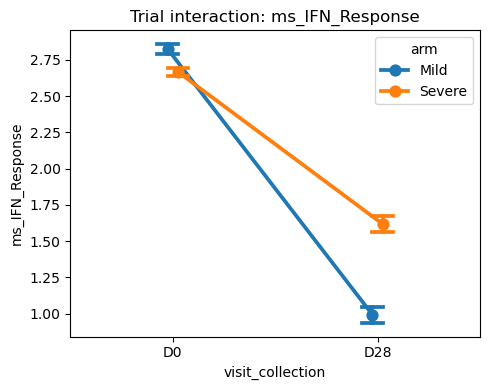

In [17]:
if features:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_trial_interaction(adata, features[0], design=design, visits=tuple(visits), ax=ax)
    plt.tight_layout(); plt.show()


## 15. Trial UMAP Panel for a Module Score
We visualize a module score across the UMAP, stratified by arm and visit.


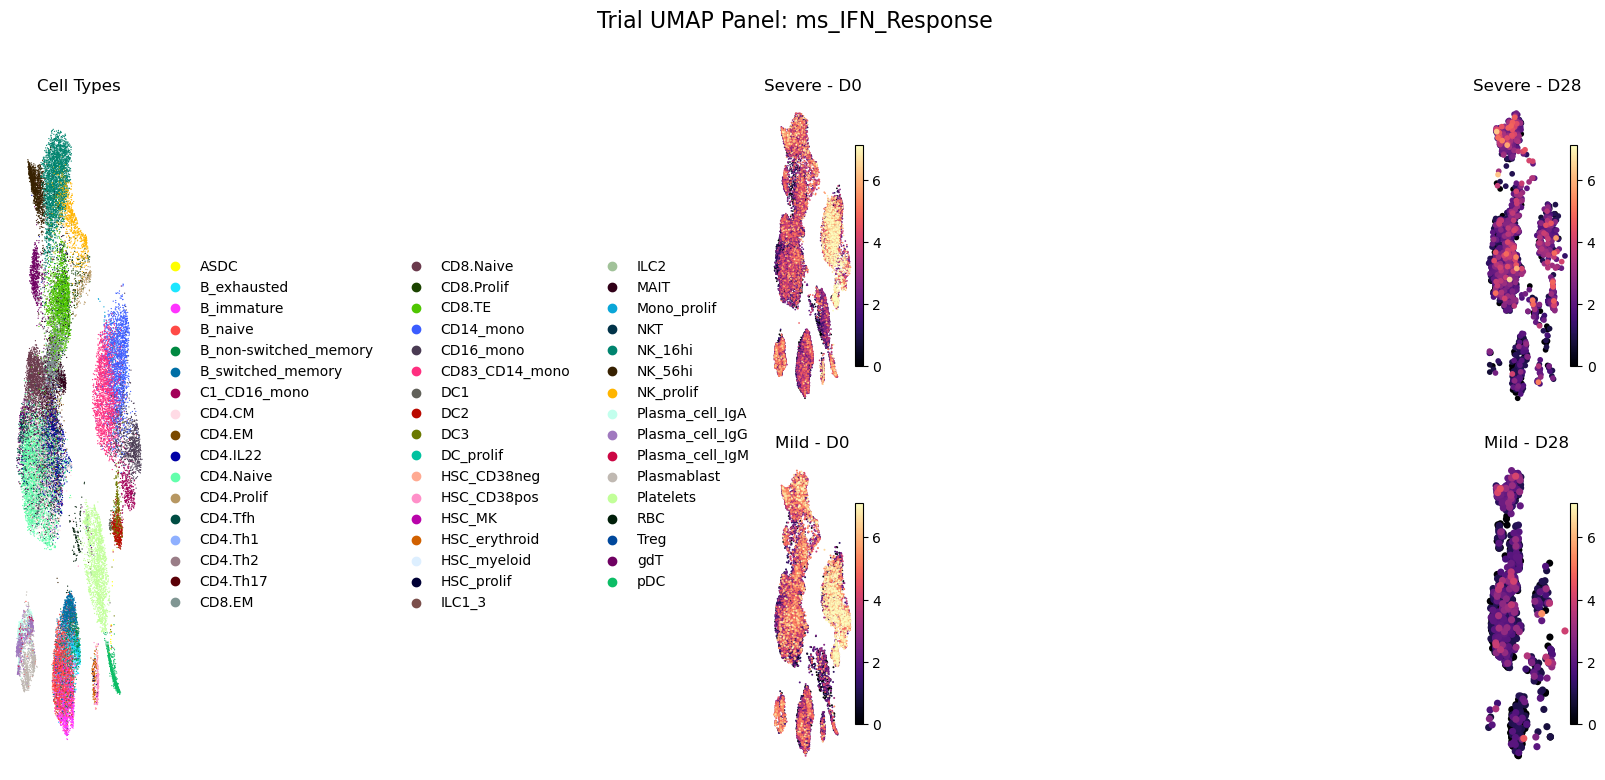

In [18]:
if features:
    st.plot_trial_umap_panel(adata, features[0], design=design, visits=tuple(visits))


## 16. Dotplot of Panel Genes
We summarize expression of selected genes across cell types and arms.


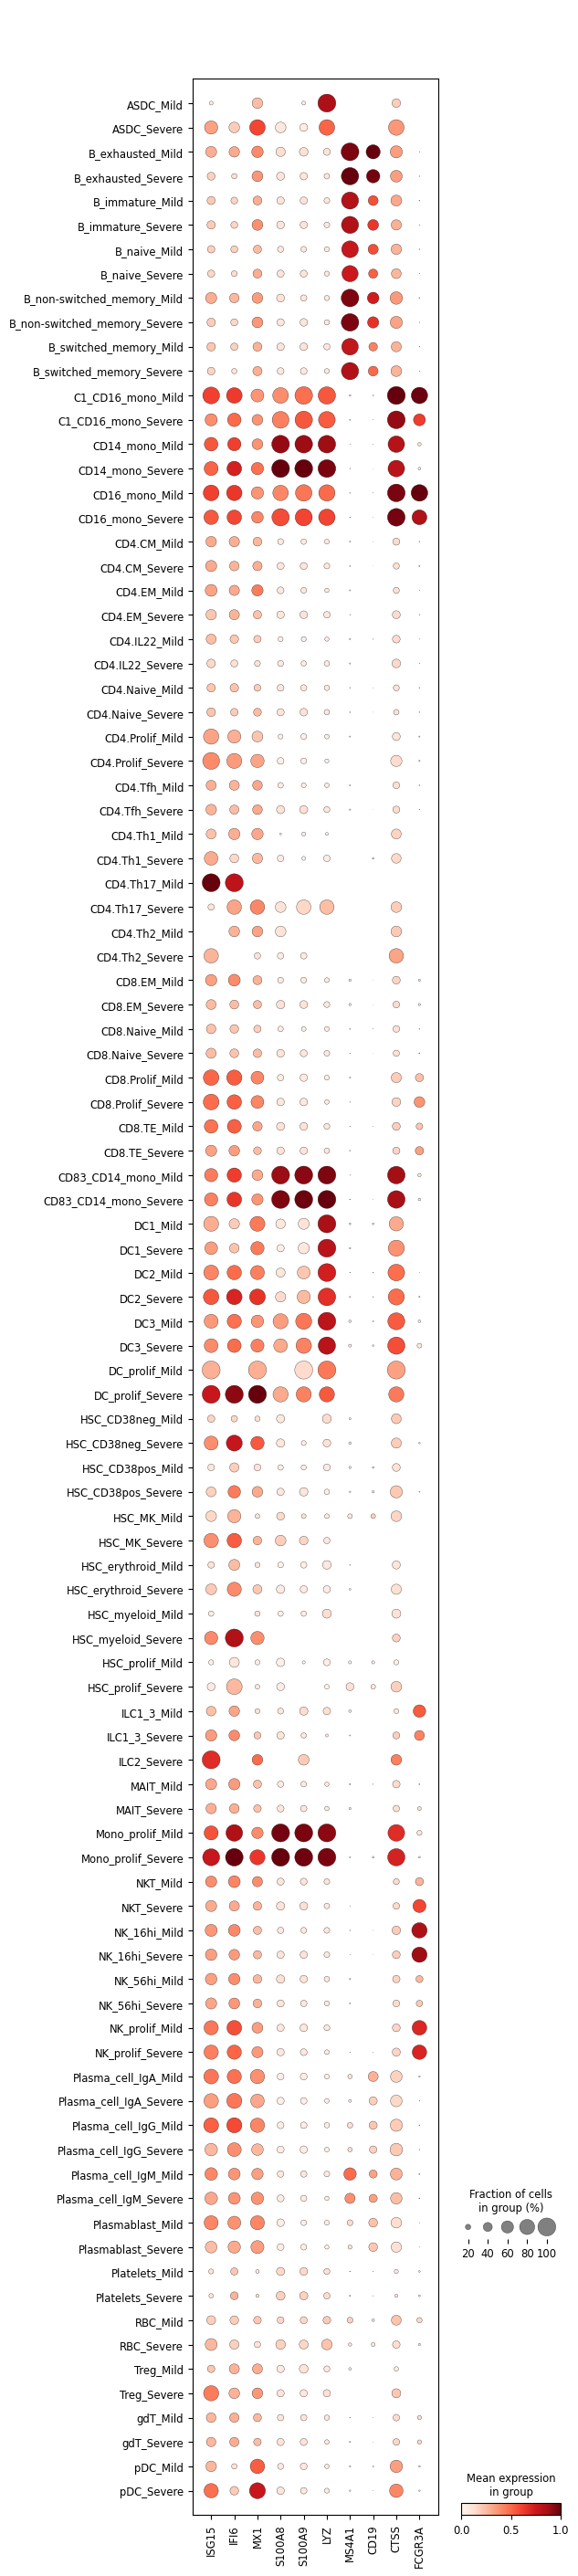

In [19]:
if panel_genes:
    st.plot_trial_dotplot(adata, panel_genes, design=design, visits=tuple(visits), standard_scale="var")
